# Trace variants, payload profiling, and Pareto selection

This lab treats variant detection as a modeling decision. We compare multiple trace encodings and selection thresholds, then identify configurations that are non-dominated across four objectives:

- case coverage;
- compactness;
- decision relevance;
- temporal stability.

**Important:** a Pareto front produces a shortlist, not an automatic winner.

## 1. Setup

The lab uses a deterministic synthetic order-handling log. This lets us know which patterns and drift were introduced while still working with realistic lifecycle and payload fields.

In [12]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

lab_dir = Path.cwd()
if not (lab_dir / "variant_pareto_lab.py").exists():
    lab_dir = Path("labs/01-variant-pareto")
sys.path.insert(0, str(lab_dir.resolve()))

from variant_pareto_lab import (
    build_case_table,
    encode_traces,
    evaluate_variant_candidates,
    generate_event_log,
    plot_pareto_candidates,
    profile_payload,
)

pd.set_option("display.max_colwidth", 100)

## 2. Inspect the event log

The minimum semantics are `case_id`, `activity`, and `timestamp`. Lifecycle transitions and payload enrich the analysis, but they also introduce representational choices.

In [13]:
events = generate_event_log()
cases = build_case_table(events)

print(f"Events: {len(events):,}")
print(f"Cases: {events['case_id'].nunique():,}")
display(events.head(12))
display(cases.head())

Events: 2,400
Cases: 240


,case_id,channel,product_type,priority,amount,customer_note,path_name,late_period,activity,lifecycle,timestamp,duration_hours,outcome
0,C-0001,web,standard,normal,348.431570,standard request,normal,False,Receive,start,2025-01-06 14:45:38.154032579,NaN,NaN
1,C-0001,web,standard,normal,348.431570,standard request,normal,False,Receive,complete,2025-01-06 15:03:20.383862896,0.295064,NaN
2,C-0001,web,standard,normal,348.431570,standard request,normal,False,Check,start,2025-01-06 15:32:30.333913849,NaN,NaN
3,C-0001,web,standard,normal,348.431570,standard request,normal,False,Check,complete,2025-01-06 17:09:18.717450346,1.613440,NaN
4,C-0001,web,standard,normal,348.431570,standard request,normal,False,Approve,start,2025-01-06 17:54:13.350284561,NaN,NaN
5,C-0001,web,standard,normal,348.431570,standard request,normal,False,Approve,complete,2025-01-06 19:21:15.295655459,1.450540,NaN
6,C-0001,web,standard,normal,348.431570,standard request,normal,False,Ship,start,2025-01-06 19:27:43.561313860,NaN,NaN
7,C-0001,web,standard,normal,348.431570,standard request,normal,False,Ship,complete,2025-01-06 22:02:30.007040761,2.579568,adverse
8,C-0002,web,standard,normal,299.429903,standard request,normal,False,Receive,start,2025-01-07 02:03:19.485490010,NaN,NaN
9,C-0002,web,standard,normal,299.429903,standard request,normal,False,Receive,complete,2025-01-07 02:37:44.874626150,0.573719,NaN


,case_id,start_time,end_time,channel,product_type,priority,amount,customer_note,path_name,outcome,completed_events,period
0,C-0001,2025-01-06 14:45:38.154032579,2025-01-06 22:02:30.007040761,web,standard,normal,348.431570,standard request,normal,adverse,4,early
1,C-0002,2025-01-07 02:03:19.485490010,2025-01-07 08:37:46.856103062,web,standard,normal,299.429903,standard request,normal,good,4,early
2,C-0003,2025-01-08 00:07:00.698108557,2025-01-08 13:22:37.745100428,web,custom,normal,91.558552,NaN,clarify,adverse,6,early
3,C-0004,2025-01-08 14:03:09.728702932,2025-01-08 23:33:34.786646833,web,standard,high,470.682300,standard request,normal,good,4,early
4,C-0005,2025-01-09 12:06:33.288399215,2025-01-10 05:05:30.141386221,web,standard,normal,678.757690,standard request,clarify,good,6,early


### Checkpoint

1. Why do some activities have `suspend` and `resume` events?
2. Which columns are repeated event payload, and which are only known at completion?
3. Would filtering to completed cases change the question we can answer?

## 3. Profile the payload before encoding it

Payload is information carried by an event beyond its basic control-flow semantics. Missingness, cardinality, drift, privacy, and availability all matter before payload becomes part of a variant or machine-learning feature.

In [14]:
payload_profile = profile_payload(events)
display(
    payload_profile.style.format(
        {"missing_rate": "{:.1%}", "drift_score": "{:.3f}"}
    )
)

,payload,available,missing_rate,cardinality,drift_score,leakage_risk
0,channel,case start,0.0%,3,0.125,False
1,product_type,case start,7.1%,3,0.017,False
2,priority,case start,0.0%,2,0.083,False
3,amount,case start,2.5%,234,0.001,False
4,customer_note,case start,26.7%,3,0.075,False
5,outcome,case completion only,0.0%,2,0.150,True


### Leakage checkpoint

`outcome` is useful for evaluating whether variants distinguish operationally relevant populations, but it is only available at case completion. It must **not** be included in an online trace encoding.

Discuss what would happen if the outcome, final activity, or a completion-only document were included in a predictive prefix.

## 4. Compare trace encodings

Exact variant counts are produced by an encoding. They are not immutable properties of the source data.

In [15]:
encoding_rows = []
traces_by_encoding = {}

for encoding in ["control_flow", "lifecycle", "time", "payload"]:
    traces = encode_traces(events, encoding)
    traces_by_encoding[encoding] = traces
    frequencies = traces.value_counts(normalize=True)
    encoding_rows.append(
        {
            "encoding": encoding,
            "exact_variants": traces.nunique(),
            "largest_variant_share": frequencies.iloc[0],
            "top_5_coverage": frequencies.head(5).sum(),
        }
    )

encoding_summary = pd.DataFrame(encoding_rows)
display(
    encoding_summary.style.format(
        {"largest_variant_share": "{:.1%}", "top_5_coverage": "{:.1%}"}
    )
)

,encoding,exact_variants,largest_variant_share,top_5_coverage
0,control_flow,5,46.7%,100.0%
1,lifecycle,9,46.7%,80.4%
2,time,40,16.2%,53.3%
3,payload,48,15.8%,41.2%


In [16]:
example_case = cases.loc[cases["path_name"] == "clarify", "case_id"].iloc[0]
print("Example case:", example_case)
for encoding, traces in traces_by_encoding.items():
    print(f"\n{encoding}:\n{traces.loc[example_case]}")

Example case: C-0003

control_flow:
('Receive', 'Check', 'Clarify', 'Check', 'Approve', 'Ship')

lifecycle:
('Receive:start', 'Receive:complete', 'Check:start', 'Check:complete', 'Clarify:start', 'Clarify:complete', 'Check:start', 'Check:suspend', 'Check:resume', 'Check:complete', 'Approve:start', 'Approve:complete', 'Ship:start', 'Ship:complete')

time:
('Receive@fast', 'Check@typical', 'Clarify@slow', 'Check@typical', 'Approve@fast', 'Ship@typical')

payload:
('Receive|web|custom', 'Check|web|custom', 'Clarify|web|custom', 'Check|web|custom', 'Approve|web|custom', 'Ship|web|custom')


### Encoding checkpoint

- Which encoding fragments the population most aggressively?
- Which encoding preserves lifecycle interruptions?
- Does payload create meaningful cohorts, or merely many one-case variants?
- Which encoding would be defensible for the question you want to answer?

## 5. Evaluate variant-detection configurations

Each candidate combines:

- one trace encoding;
- an edit-similarity threshold (`1.00`, `0.80`, or `0.65`);
- a minimum variant frequency (`1`, `6`, or `20` cases).

All four objectives are maximized. Decision relevance uses the outcome only as an evaluation signal.

In [17]:
candidates, labels_by_candidate = evaluate_variant_candidates(events)
metric_columns = [
    "candidate_id",
    "coverage",
    "compactness",
    "decision_relevance",
    "temporal_stability",
    "retained_variants",
    "pareto",
]
display(
    candidates[metric_columns].head(12).style.format(
        {
            "coverage": "{:.3f}",
            "compactness": "{:.3f}",
            "decision_relevance": "{:.3f}",
            "temporal_stability": "{:.3f}",
        }
    )
)

,candidate_id,coverage,compactness,decision_relevance,temporal_stability,retained_variants,pareto
0,lifecycle|sim=0.80|min=1,1.000,0.983,0.267,0.870,5,True
1,control_flow|sim=0.80|min=1,1.000,0.987,0.262,0.874,4,True
2,control_flow|sim=0.80|min=20,0.925,0.992,0.262,0.874,3,True
3,lifecycle|sim=0.80|min=20,0.892,0.992,0.271,0.873,3,True
4,control_flow|sim=0.65|min=1,1.000,0.996,0.085,0.946,2,True
5,control_flow|sim=0.65|min=20,0.925,1.000,0.085,0.946,1,True
6,lifecycle|sim=0.65|min=20,0.871,0.996,0.154,0.869,2,True
7,lifecycle|sim=1.00|min=20,0.604,0.996,0.262,0.872,2,True
8,time|sim=0.65|min=20,0.667,1.000,0.018,0.985,1,True
9,time|sim=1.00|min=20,0.463,0.987,0.108,0.883,4,True


## 6. Inspect the Pareto front

The plot is a two-dimensional projection. Pareto membership is calculated using all four objectives, so a point can be non-dominated even when another point appears better in this projection.

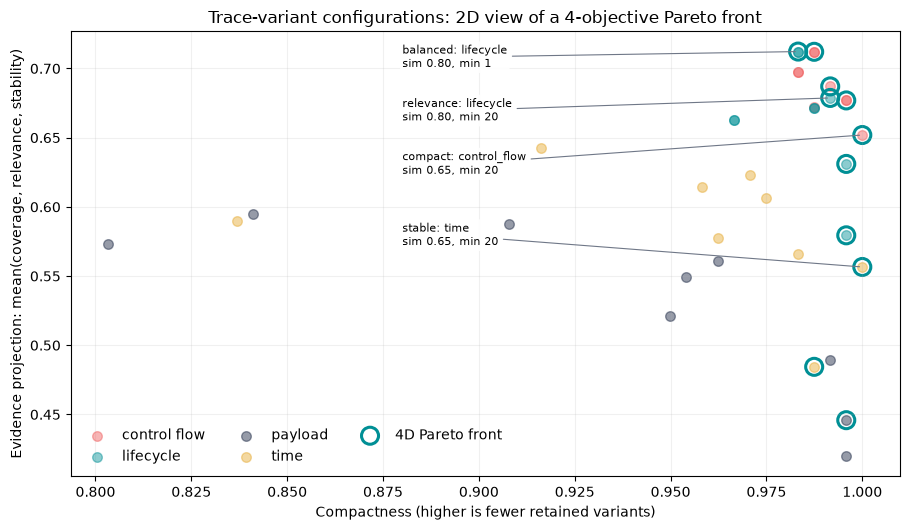

,candidate_id,coverage,compactness,decision_relevance,temporal_stability,retained_variants,pareto
0,lifecycle|sim=0.80|min=1,1.000000,0.983264,0.266805,0.869893,5,True
1,control_flow|sim=0.80|min=1,1.000000,0.987448,0.261699,0.874484,4,True
2,control_flow|sim=0.80|min=20,0.925000,0.991632,0.261699,0.874484,3,True
3,lifecycle|sim=0.80|min=20,0.891667,0.991632,0.271346,0.873151,3,True
4,control_flow|sim=0.65|min=1,1.000000,0.995816,0.084743,0.946049,2,True
5,control_flow|sim=0.65|min=20,0.925000,1.000000,0.084743,0.946049,1,True
6,lifecycle|sim=0.65|min=20,0.870833,0.995816,0.153551,0.868745,2,True
7,lifecycle|sim=1.00|min=20,0.604167,0.995816,0.262137,0.872028,2,True
8,time|sim=0.65|min=20,0.666667,1.000000,0.018047,0.984985,1,True
9,time|sim=1.00|min=20,0.462500,0.987448,0.107822,0.882890,4,True


In [18]:
fig, axis = plot_pareto_candidates(candidates)
plt.show()

pareto_front = candidates[candidates["pareto"]]
display(pareto_front[metric_columns])

## 7. Apply constraints before preferences

Assume the stakeholders require at least 80% case coverage and 75% temporal stability. We first remove infeasible candidates, then inspect the remaining Pareto alternatives. Preferences come afterward.

In [19]:
feasible_front = pareto_front.query(
    "coverage >= 0.80 and temporal_stability >= 0.75"
).copy()

feasible_front["stakeholder_view"] = (
    0.55 * feasible_front["decision_relevance"]
    + 0.45 * feasible_front["compactness"]
)

display(
    feasible_front.sort_values("stakeholder_view", ascending=False)[
        metric_columns + ["stakeholder_view"]
    ]
)

,candidate_id,coverage,compactness,decision_relevance,temporal_stability,retained_variants,pareto,stakeholder_view
3,lifecycle|sim=0.80|min=20,0.891667,0.991632,0.271346,0.873151,3,True,0.595474
2,control_flow|sim=0.80|min=20,0.925000,0.991632,0.261699,0.874484,3,True,0.590169
0,lifecycle|sim=0.80|min=1,1.000000,0.983264,0.266805,0.869893,5,True,0.589211
1,control_flow|sim=0.80|min=1,1.000000,0.987448,0.261699,0.874484,4,True,0.588286
6,lifecycle|sim=0.65|min=20,0.870833,0.995816,0.153551,0.868745,2,True,0.532570
5,control_flow|sim=0.65|min=20,0.925000,1.000000,0.084743,0.946049,1,True,0.496609
4,control_flow|sim=0.65|min=1,1.000000,0.995816,0.084743,0.946049,2,True,0.494726


### Selection exercise

Choose one feasible configuration and write a short justification covering:

1. the analytical question;
2. why its encoding is meaningful;
3. what is gained and lost relative to an adjacent Pareto candidate;
4. representative traces you would inspect before approval;
5. payload, fairness, privacy, or leakage limitations;
6. how the configuration would be validated on a later time period.

## Optional PM4Py extension

If PM4Py is installed, convert the event table and compare its exact control-flow variants with the implementation used here:

```python
import pm4py

pm_log = pm4py.format_dataframe(
    events.query("lifecycle == 'complete'"),
    case_id='case_id',
    activity_key='activity',
    timestamp_key='timestamp',
)
pm4py.get_variants_as_tuples(pm_log)
```

Explain why lifecycle-, time-, and payload-aware variants require an explicit encoding decision before calling a variant-discovery function.

In [21]:
import pm4py

pm_log = pm4py.format_dataframe(
    events.query("lifecycle == 'complete'"),
    case_id='case_id',
    activity_key='activity',
    timestamp_key='timestamp',
)
pm4py.get_variants_as_tuples(pm_log)



  Welcome to PM4Py — Community Version
  Open-Source License (AGPL v3)

  📚 Docs & Examples:
     https://processintelligence.solutions/pm4py

  ⚖️  License: AGPL v3 — Commercial use requires open-sourcing your application.
     Business use without open-sourcing? A commercial license is available:
     https://processintelligence.solutions/pm4py#licensing




{('Receive', 'Check', 'Approve', 'Ship'): 112,
 ('Receive', 'Check', 'Clarify', 'Check', 'Approve', 'Ship'): 50,
 ('Receive', 'Check', 'Approve', 'Rework', 'Approve', 'Ship'): 27,
 ('Receive', 'Check', 'Approve', 'Pack', 'Ship'): 33,
 ('Receive', 'Check', 'Reject'): 18}